# RES Hill of Towie Simulations

## 1. SCADA Data Simulations (10min granularity)

### 1.1 Initialization

Import SCADA Data from T01:

In [2]:
import pandas as pd
from hot_open.settings import get_data_dir
from hot_open.scada_helpers import load_hot_10min_data

start = pd.Timestamp("2026-02-20 00:00", tz="UTC")
end_excl = pd.Timestamp("2026-02-20 04:30", tz="UTC")   # bis und ohne -> letzter Zeitstempel 04:20

scada = load_hot_10min_data(
    data_dir=get_data_dir(),
    wtg_numbers=range(1, 22),    # alle 21 Turbinen, für vergleich später
    start_dt=start,
    end_dt_excl=end_excl,
)

# Peak at data for T01:
# scada["T01"][["wtc_AcWindSp_mean", "wtc_NacelPos_mean", "wtc_ActPower_mean"]]

unpacking 2026: 100%|██████████| 4/4 [00:08<00:00,  2.14s/it]


Import Turbine Metadata

In [3]:
from hot_open.sourcing_data import ensure_hot_data_files
from hot_open.settings import get_data_dir
import pandas as pd

# Nur die Turbinen-Metadaten anfordern (kleine Dateien wie Reports werden automatisch mitgeladen)
ensure_hot_data_files(["Hill_of_Towie_turbine_metadata.csv"])

data_dir = get_data_dir()
turbine_metadata = pd.read_csv(data_dir / "Hill_of_Towie_turbine_metadata.csv")

Create generic SWT23 turbines

In [4]:
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine

rated_power_kw = turbine_metadata["Rated power (kW)"].iloc[0]    # 2300 kW
rotor_diameter = turbine_metadata["Rotor Diameter (m)"].iloc[0]  # 82 m
hub_height = turbine_metadata["Hub Height (m)"].iloc[0]          # 59 m

swt23 = GenericWindTurbine(
    name="SWT-2.3-VS-82",
    diameter=rotor_diameter,
    hub_height=hub_height,
    power_norm=rated_power_kw,
    turbulence_intensity=0.1,
)

c:\Users\ryan.feusi\hill-of-towie-open-source-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import locations of WTs and transform them from lat/long to relative x-,y-positions

In [5]:
from pyproj import Transformer

# WGS84 (Lat/Lon in Grad) -> UTM Zone 30N (Meter) - passt für Schottland/Hill of Towie
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)

lon = turbine_metadata["Longitude"].to_numpy()
lat = turbine_metadata["Latitude"].to_numpy()
utm_x, utm_y = transformer.transform(lon, lat)

# Ursprung auf die Ecke des Windparks legen -> kleinere, handlichere Zahlen
x = utm_x - utm_x.min()
y = utm_y - utm_y.min()

### 1.2 Plot with 10min SCADA data

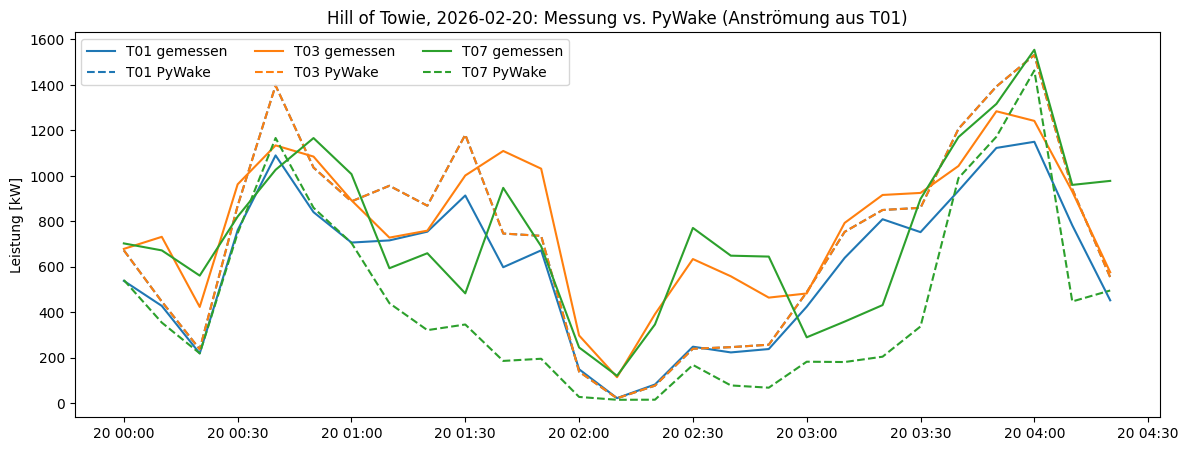

In [ ]:
import matplotlib.pyplot as plt
from py_wake.site import UniformSite
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014

# Alle NaNs löschen, damit die Simulationsfunktion keine Probleme bekommt
t01 = scada["T01"].dropna(subset=["wtc_AcWindSp_mean", "wtc_NacelPos_mean"]) # type: ignore

ws_t01 = t01["wtc_AcWindSp_mean"].to_numpy()
wd_t01 = (t01["wtc_NacelPos_mean"].to_numpy() - 23.5675) % 360
time = t01.index.tz_convert(None).to_numpy()   # UTC, aber ohne Zeitzonen-Markierung

site = UniformSite(p_wd=[1], ti=0.1) # T01 Daten für alle Turbinen gleich
wf_model = Bastankhah_PorteAgel_2014(site, swt23, k=0.0324555)
sim_res = wf_model(x, y, wd=wd_t01, ws=ws_t01, time=time)

# Simulierte Leistung [kW], gleiche Form wie die Messdaten: Zeile = Zeit, Spalte = Turbine
power_sim = sim_res.Power.to_pandas().T / 1000 # type: ignore
power_sim.index = t01.index
power_sim.columns = turbine_metadata["Turbine Name"].to_list()

# Gemessene Leistung aller Turbinen [kW]+
power_meas = scada.xs("wtc_ActPower_mean", axis=1, level=1).loc[t01.index]

fig, ax = plt.subplots(figsize=(14, 5))
for name, color in [("T01", "tab:blue"), ("T03", "tab:orange"), ("T07", "tab:green")]:
    ax.plot(power_meas.index, power_meas[name], color=color, label=f"{name} gemessen")
    ax.plot(power_sim.index, power_sim[name], color=color, ls="--", label=f"{name} PyWake")
ax.set_ylabel("Leistung [kW]")
ax.set_title("Hill of Towie, 2026-02-20: Messung vs. PyWake (Anströmung aus T01)")
ax.legend(ncol=3)

### Wake Flowmap

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


# Initialisierung der Simulationsparameter
t01 = scada["T01"].dropna(subset=["wtc_AcWindSp_mean", "wtc_NacelPos_mean"])
ws_t01 = t01["wtc_AcWindSp_mean"].to_numpy()
wd_t01 = (t01["wtc_NacelPos_mean"].to_numpy() - 23.5675) % 360
time = t01.index.tz_convert(None).to_numpy()   # UTC, aber ohne Zeitzonen-Markierung


# Simulation für einen bestimmten Zeitschritt durchführen
i = 8  # 00:00 + 8 x 10 min = 01:20
print(pd.Timestamp(time[i]), wd_t01[i], ws_t01[i])   # kontrollieren, dass es der richtige Zeitschritt ist

fm = sim_res.flow_map(time=time[i])

fig, ax = plt.subplots(figsize=(10, 8))
fm.plot_wake_map(ax=ax)
for name, xi, yi in zip(turbine_metadata["Turbine Name"], x, y):
    ax.annotate(name, (xi, yi), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_title(f"PyWake {pd.Timestamp(time[i])} UTC, wd={wd_t01[i]:.0f}°, ws={ws_t01[i]:.1f} m/s")

NameError: name 'scada' is not defined

# 2. Turbine Fastlog Simulations (1sec granularity) 

### 2.1 CW steer (wake deflected west of T07)

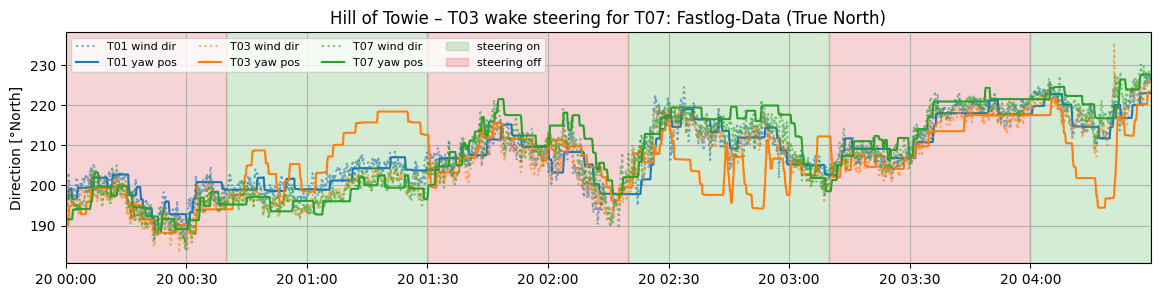

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from hot_open.fastlog_helpers import load_hot_fl_data
from hot_open.settings import get_filestore_dir

start = pd.Timestamp("2026-02-20 00:00", tz="UTC")
end_excl = pd.Timestamp("2026-02-20 04:30", tz="UTC")

dy_tags = [
    "computed_driver_pre_processed_yaw_direction_true_degrees",
    "computed_core_post_processed_consensus_wind_direction_true_degrees",
    "computed_driver_post_processed_toggle_state",
    "computed_core_post_processed_core_wake_steering_offset_degrees",
]

fl = load_hot_fl_data(
    data_dir=get_filestore_dir(),
    wtg_numbers=[1, 3, 7],
    start_dt=start,
    end_dt_excl=end_excl,
    extra_tags=dy_tags,
)

YAW = "computed_driver_pre_processed_yaw_direction_true_degrees"
WD = "computed_core_post_processed_consensus_wind_direction_true_degrees"
TOGGLE = "computed_driver_post_processed_toggle_state"

colors = {"T01": "tab:blue", "T03": "tab:orange", "T07": "tab:green"}

fig, ax = plt.subplots(figsize=(14, 3))
for name, c in colors.items():
    ax.plot(fl.index, fl[(name, WD)], color=c, ls=":", alpha=0.6, label=f"{name} wind dir")
    ax.plot(fl.index, fl[(name, YAW)], color=c, label=f"{name} yaw pos")

# Steering-Phasen von T03 hinterlegen
toggle = fl[("T03", TOGGLE)]
ax.fill_between(fl.index, 0, 1, where=(toggle == 1), transform=ax.get_xaxis_transform(),
                color="tab:green", alpha=0.2, label="steering on")
ax.fill_between(fl.index, 0, 1, where=(toggle == 0), transform=ax.get_xaxis_transform(),
                color="tab:red", alpha=0.2, label="steering off")

ax.set_ylabel("Direction [°North]")
ax.set_title("Hill of Towie – T03 wake steering for T07: Fastlog-Data (True North)")
ax.legend(ncol=4, fontsize=8)
ax.grid()
ax.margins(x=0)